Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset (upload in Colab or use path)
df = pd.read_csv('/content/nanotox_dataset.csv')

df.head()

,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class
0,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.001,1.61,3,nonToxic
1,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.010,1.61,3,nonToxic
2,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.100,1.61,3,nonToxic
3,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,1.000,1.61,3,nonToxic
4,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,5.000,1.61,3,nonToxic


Data Preprocessing

🔹 Handle Missing Values

In [3]:
df.isnull().sum()

# Simple approach
df.fillna(df.mean(numeric_only=True), inplace=True)

🔹 Encode Categorical Column (NPs)

In [4]:
le_np = LabelEncoder()
df['NPs'] = le_np.fit_transform(df['NPs'])

🔹 Encode Target Variable

In [5]:
le_target = LabelEncoder()
df['class'] = le_target.fit_transform(df['class'])  # toxic = 1, nonToxic = 0

🔹 Feature Scaling

In [6]:
X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Model Training (Baseline)

In [8]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9491525423728814
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        93
           1       0.97      0.92      0.94        84

    accuracy                           0.95       177
   macro avg       0.95      0.95      0.95       177
weighted avg       0.95      0.95      0.95       177



Avoid Overfitting (Hyperparameter Tuning)

In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.9548022598870056


Confusion Matrix

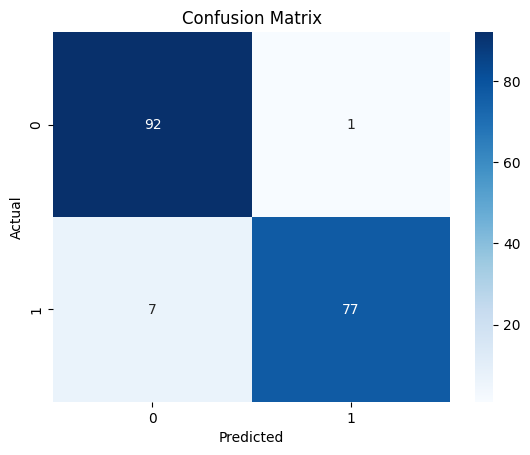

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance

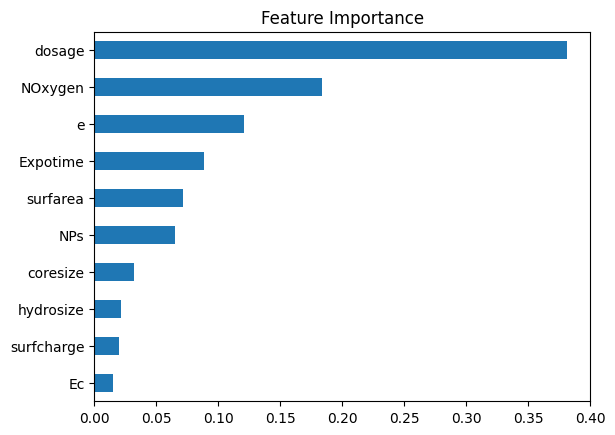

In [11]:
importances = best_model.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()